In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


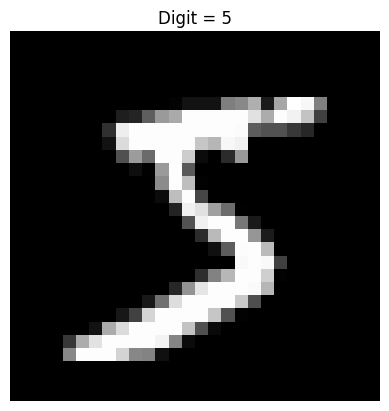

In [ ]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit = {y_train[0]}")
plt.axis("off")
plt.show()

In [ ]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

Label: 5


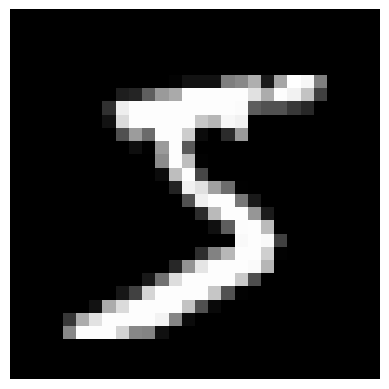

In [ ]:
print("Label:", y_train[0])

plt.imshow(X_train[0], cmap="gray")
plt.axis("off")
plt.show()

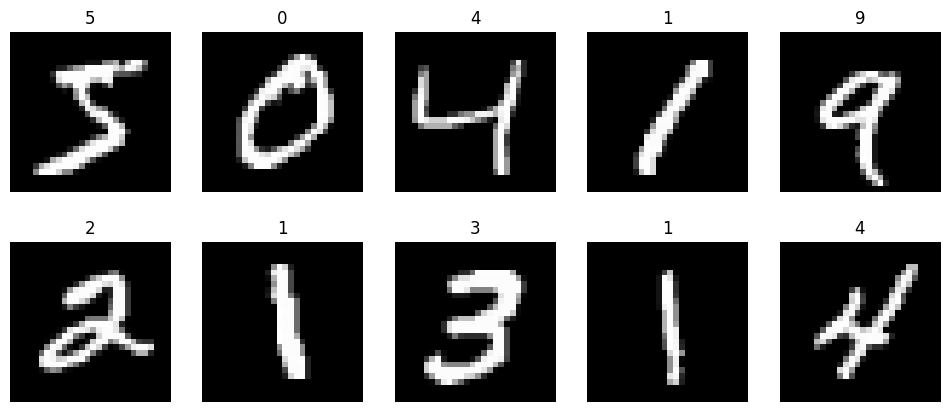

In [ ]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [ ]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit} : {count}")

Digit 0 : 5923
Digit 1 : 6742
Digit 2 : 5958
Digit 3 : 6131
Digit 4 : 5842
Digit 5 : 5421
Digit 6 : 5918
Digit 7 : 6265
Digit 8 : 5851
Digit 9 : 5949


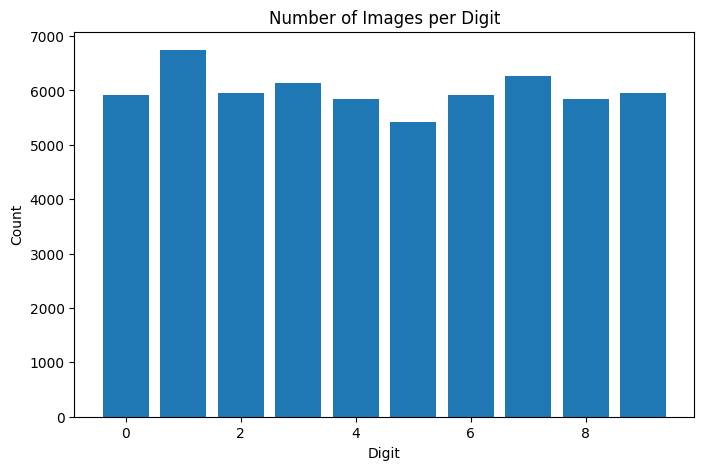

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Number of Images per Digit")

plt.show()

In [ ]:
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [ ]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [27]:
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

In [28]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [29]:
model.add(
    Flatten()
)

In [30]:
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [31]:
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.9570 - loss: 0.1431 - val_accuracy: 0.9831 - val_loss: 0.0574
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9854 - loss: 0.0451 - val_accuracy: 0.9882 - val_loss: 0.0393
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.9894 - loss: 0.0315 - val_accuracy: 0.9884 - val_loss: 0.0407
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9929 - loss: 0.0222 - val_accuracy: 0.9887 - val_loss: 0.0397
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9942 - loss: 0.0166 - val_accuracy: 0.9883 - val_loss: 0.0458
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9953 - loss: 0.0132 - val_accuracy: 0.9902 - val_loss: 0.0432
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9910 - val_loss: 0.0395
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9973 -

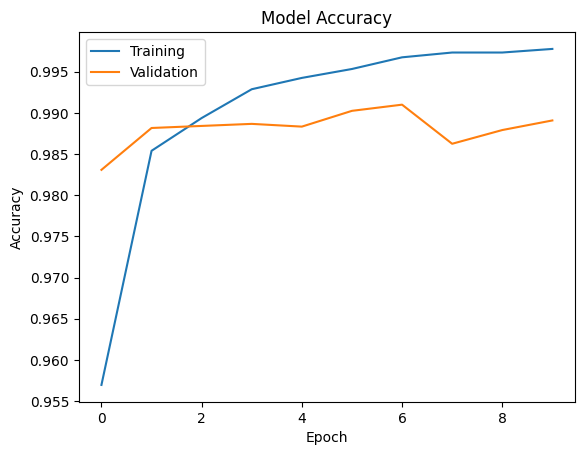

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

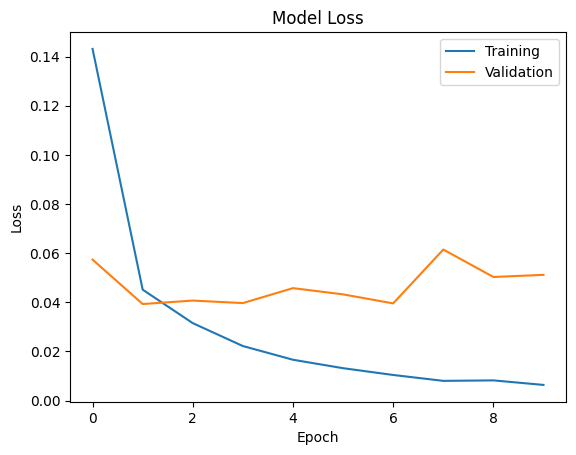

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9897 - loss: 0.0367
Test Accuracy: 0.9897000193595886


In [38]:
model.save("handwritten_digit_model.keras")

In [39]:
import os

print(os.listdir())

['.config', 'handwritten_digit_model.keras', 'sample_data']


In [40]:
from tensorflow.keras.models import load_model

loaded_model = load_model("handwritten_digit_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


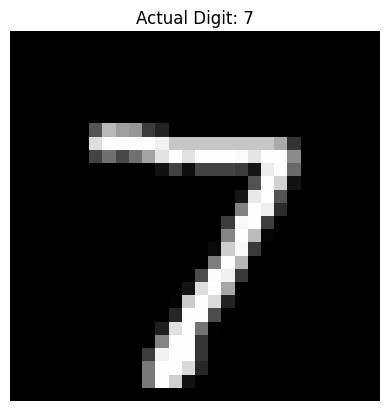

In [41]:
import numpy as np
import matplotlib.pyplot as plt

index = 0

image = X_test[index]

plt.imshow(image.reshape(28,28), cmap="gray")
plt.title(f"Actual Digit: {y_test[index]}")
plt.axis("off")
plt.show()

In [42]:
prediction = loaded_model.predict(
    image.reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Predicted Digit: 7


In [43]:
confidence = np.max(prediction)

print("Confidence:", confidence*100, "%")

Confidence: 100.0 %


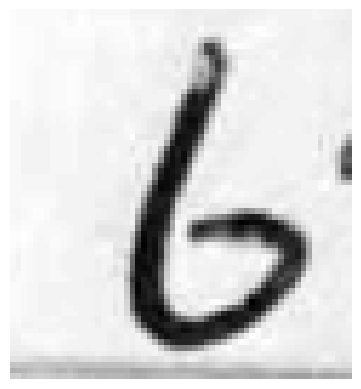

In [59]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(
    "SIX.PNG",
    color_mode="grayscale"
)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

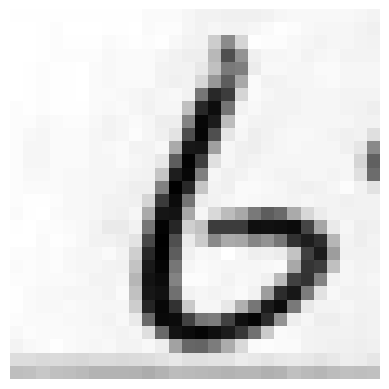

In [60]:
img = img.resize((28,28))

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [61]:
img_array = np.array(img)

print(img_array.shape)

(28, 28)


In [62]:
img_array = img_array / 255.0
img_array = 1 - img_array

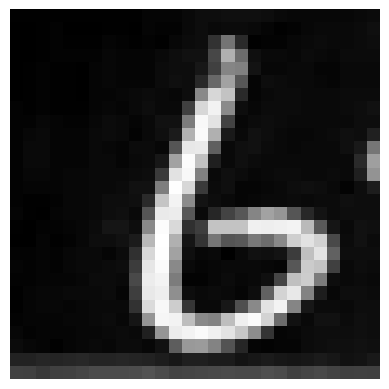

In [63]:
plt.imshow(img_array.reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()

In [64]:
prediction = loaded_model.predict(img_array.reshape(1,28,28,1))

digit = np.argmax(prediction)

confidence = np.max(prediction)

print("Predicted Digit:", digit)
print("Confidence:", confidence*100,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Digit: 6
Confidence: 41.218582 %
